In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ast import literal_eval

In [2]:
bd= pd.read_csv('datafixed_bolide_data.csv') #the index for bolide 1 is 12

In [3]:
b3= bd.iloc[52]

In [4]:
b3['duration']

0.161364

In [5]:
lat= literal_eval(b3['lat_stereo_g16'])
long= literal_eval(b3['lon_stereo_g16'])
alt= literal_eval(b3['alt_stereo_g16'])
energy = literal_eval(b3['energyJoules_stereo_g16'])

In [6]:
def findtheta(lat, long, alt):
    x= np.abs(lat[-1]-lat[0])*0.0175
    y= np.abs(long[-1]-long[0])*0.0175
    z= np.abs(alt[-1]-alt[0])
    return np.arctan((np.sqrt(x**2+y**2))/z)

def degtom(theta, r=6378137): #r in m
    rad= theta*0.0175
    return r*rad

def airrho(z, H=8500): #calculates density based on rho naught, height, and scale height
                                    #8.5 km is the scale height for Earth and 1.225 kg/m^3 is the density of air at sea level
    return (rho0*(1/(np.e**(z/H))))

bestfit= [] #bestfit must be defined outside of the function so that it can be used as a variable

def linearregression(x, y): #create a linear best fit for some data x and y
    sumxy=0 #need to be computed in a loop (cant use np.sum) so they're defined as 0 here and then summed later
    sumxsquare= 0
    sumx = np.sum(x)
    sumy = np.sum(y)
    n = len(x)
    for i in range(len(x)): #compute the correct sum(x*y)
        sumxy= sumxy+(x[i]*y[i])
    for i in range (len(x)): #compute the correct sun(x**2). this is DIFFERENT than sum(x)**2
        sumxsquare = sumxsquare + x[i]**2

    atop = (sumy*sumxsquare) - (sumx*sumxy) #defining atop and abottom separately to avoid accidentally coding in silly errors
    abottom = (n*sumxsquare) - sumx**2
    a = atop/abottom #a is our intercept in our linear equation. equavalent to b in y=mx+b but a+bx is the statistical notation I found
    btop = (n*sumxy) - (sumx*sumy) #similarly splitting b to avoid errors
    bbottom = (n*sumxsquare) - sumx**2
    b = btop/bbottom #b is the slope of our linear equation
    plt.scatter(x,y) #plot our original data as a scatter plot
    plt.plot (x, (a+b*x)) #plot our best fit line on the same graph

    for i in range (len(x)): #lastly...
        bestfit.append (a+b*x[i]) #... append each point on our best fit line to a list we can use for later calculations!

H=8500 #meters
rho0= 1.225 #kg/m^3
rockyrho = 3500 #kg/m^3
metalrho = 7500 #kg/m^3 #constants for bolide density based on possible composition
icyrho = 750 #kg/m^3

In [7]:
print (len(lat), len(long), len(alt), len(energy))

68 68 68 68


In [8]:
for i in range(len(energy)):
    if energy[i] == np.max(energy):
        print(i) #determine the index at which the bolide catastrophically destructs

43


In [9]:
totalmass= 0
totalh= 0 
for i in range (43): 
    deltalat = np.abs(degtom(lat[i+1]-lat[i])) #change in lat converted to meters 
    deltalong = np.abs(degtom(long[i+1]-long[i]))
    deltaalt = (np.abs(alt[i+1]-alt[i]))*1000 #multipled by 1000 to convert to meters
    h= np.sqrt(deltalat**2 + deltalong**2 + deltaalt**2)
    totalh= totalh+h 

    altm = (alt[i]+alt[i+1])*1000
    rho = airrho((1/2)*altm)
    totalmass = totalmass+(h*rho)

In [10]:
rrocky = (3/4)*(totalmass/rockyrho)
rmetal = (3/4)*(totalmass/metalrho)
ricy = (3/4)*(totalmass/icyrho)

print (rrocky, rmetal, ricy) #this unit is METERS 

0.00010919605676416035 5.0958159823274836e-05 0.0005095815982327483


In [11]:
totalh

8456.474660482036

In [12]:
for i in range(len(alt)-1):
    print (alt[i]-alt[i+1])

0.0011624400000016522
-0.0004065899999972089
-0.0010856699999948205
-0.001538280000005443
-0.0006436000000036302
0.0006112900000090349
0.0008456399999943187
0.0008324799999996912
0.0010553900000047634
0.0006288699999998926
-0.0010833000000047832
-0.001319469999998546
-0.0008878999999950565
0.000683029999990481
1.5872401299999979
0.5582441300000056
1.429310430000001
-0.000672539999996502
-0.0006784800000048108
-0.0008934699999940676
-0.0008978800000107867
6.400000103212733e-07
0.0015706099999874823
0.0015584799999999177
0.0024906200000032186
0.0024927700000034747
0.0015920999999963215
-0.0001895699999892031
-0.00018742000000315784
-0.0015521300000074234
0.0603528099999977
0.028156190000004244
0.025165209999997273
0.043070000000000164
0.03271073000000513
0.04859947999999292
0.04488621000000137
0.04119168000001139
0.0530769199999952
0.04769722999999715
0.041071279999997046
0.03956540000000075
0.040148060000007035
0.028151699999995117
0.02378563999999983
0.04085231000000533
0.0393330099999

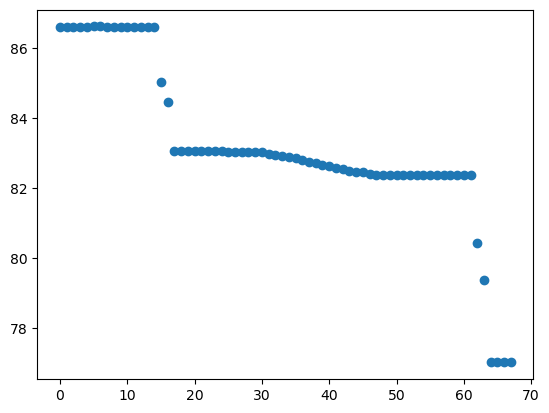

In [13]:
plt.scatter(range(len(alt)), alt)

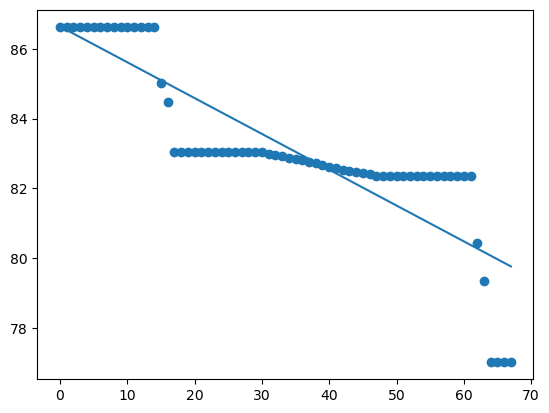

In [14]:
linearregression(range(len(alt)), alt)

In [15]:
totalmass= 0
totalh= 0 
for i in range (43): 
    deltalat = np.abs(degtom(lat[i+1]-lat[i])) #change in lat converted to meters 
    deltalong = np.abs(degtom(long[i+1]-long[i]))
    deltaalt = (np.abs(bestfit[i+1]-bestfit[i]))*1000 #multipled by 1000 to convert to meters
    h= np.sqrt(deltalat**2 + deltalong**2 + deltaalt**2)
    totalh= totalh+h 

    altm = (bestfit[i]+bestfit[i+1])*1000
    rho = airrho((1/2)*altm)
    totalmass = totalmass+(h*rho)

In [16]:
rrocky = (3/4)*(totalmass/rockyrho)
rmetal = (3/4)*(totalmass/metalrho)
ricy = (3/4)*(totalmass/icyrho)

print (rrocky, rmetal, ricy) #this unit is METERS 

0.0001317746379922497 6.149483106304986e-05 0.0006149483106304986
